In [1]:
import sys
sys.path.append(r'/import/home2/yzengbj/my_project/code')
import SVF

import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt

import simulation as construct_st

import warnings
warnings.filterwarnings("ignore")
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
DATA_PATH = "/import/home2/share/yqzeng/MacSPG/data/simulation/final" # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSPG/results/simulation/final" # Deconvolution results
os.makedirs(os.path.join(DATA_PATH), exist_ok = True)
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [3]:
factor_pattern = 'gradient_y'
factor_celltype = [0]

n_spots = 3000
n_genes = 2000
n_celltypes = 2
n_cells = 500
n_covariates = 1
n_loading_genes = 200

n_groups = 4
ref_noise_ratio = 10

library_size = 5000
prop_confound = True

prop_min = 0.1
prop_max = 0.9

same_tau = True

spots_effects = False
platform_effects = False

shifted = False
c = 1

In [4]:
adata_ref, adata_st, reference, logmu = construct_st.simulate_data_2ct(
    seed=20250723,
    n_spots=n_spots, n_genes=n_genes,
    library_size=np.ones(n_spots) * library_size,
    n_celltypes=n_celltypes,
    n_cells=n_cells,
    n_covariates=n_covariates,
    n_groups=n_groups,
    ref_noise_ratio=ref_noise_ratio,
    same_tau=same_tau,
    prop_confound=prop_confound,
    prop_min=prop_min, prop_max=prop_max,
    spot_effects=spots_effects, platform_effects=platform_effects,
    factor=True, n_loading_gene=n_loading_genes,
    factor_celltypes=factor_celltype, factor_pattern=factor_pattern,
    shifted=False, c = 0.001, 
)

Reference generated
Tau generated
Single cell data generated
Coordinates generated
Proportion generated
Covariates generated
mu generated
Lambda generated
Reference data generated
Spatial data generated


In [5]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP

In [6]:
MacSGP.utils.Cal_Spatial_Net(adata_st, mode='KNN', k_cutoff=12)

Calculating spatial neighbor graph ...
The graph contains 40806 edges, 3000 spots.
13.602 neighbors per spot on average.


In [7]:
adata_st, adata_basis = MacSGP.utils.preprocess(adata_st,adata_ref,
                                                celltype_ref_col = "celltype",
                                                n_hvg_group = 1000)

Finding highly variable genes...
2000 highly variable genes selected.
Calculate basis for deconvolution...
Preprocess ST data...


In [8]:
model = MacSGP.model.Model_deconv(adata_st, adata_basis, n_layers =4, training_steps=10000)
model.train(step_interval=1000)
adata_st = model.eval()

  0%|          | 9/10000 [00:02<37:24,  4.45it/s]  

Step: 0, Loss: -736.1868, d_loss: -743.5078, f_loss: 73.2095


 10%|█         | 1026/10000 [00:11<01:12, 123.85it/s]

Step: 1000, Loss: -930.1940, d_loss: -933.8029, f_loss: 36.0887


 20%|██        | 2021/10000 [00:19<01:05, 121.14it/s]

...

 80%|████████  | 8013/10000 [01:08<00:16, 123.90it/s]

Step: 8000, Loss: -931.3475, d_loss: -934.9190, f_loss: 35.7148


 90%|█████████ | 9022/10000 [01:16<00:07, 137.57it/s]

Step: 9000, Loss: -931.3655, d_loss: -934.9211, f_loss: 35.5562


100%|██████████| 10000/10000 [01:23<00:00, 119.20it/s]


In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [10]:
adata_st.obs['ct'] = adata_st.obsm['proportion'].idxmax(axis=1)

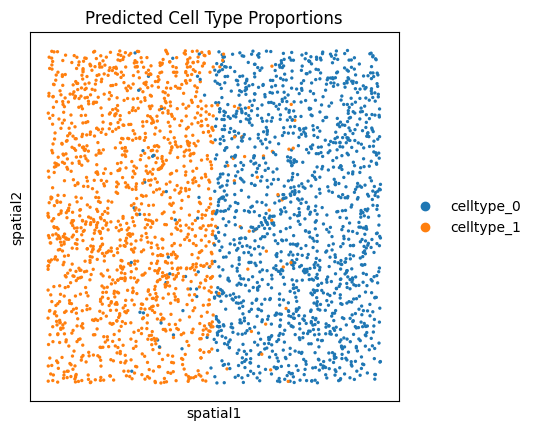

In [11]:
sc.pl.spatial(adata_st, color='ct', title='Predicted Cell Type Proportions', spot_size=0.01)

In [12]:
adata_st_ct = adata_st[adata_st.obs['ct']=='celltype_0'].copy()
sc.tl.pca(adata_st_ct, n_comps=min(10, adata_st_ct.n_obs - 1, adata_st_ct.n_vars - 1))

In [13]:
model = MacSGP.model.Model(adata_st, adata_basis, n_layers=4, training_steps=3000)

model.train(step_interval=600)
adata_result = model.eval()

  0%|          | 9/3000 [00:00<01:06, 44.80it/s]

Step: 0, Loss: -927.6000, d_loss: -934.9209, f_loss: 73.2095, reg_loss: 0.0000


 20%|██        | 614/3000 [00:08<00:33, 71.42it/s]

Step: 600, Loss: -944.7094, d_loss: -951.2840, f_loss: 36.1229, reg_loss: 0.2669


 40%|████      | 1214/3000 [00:16<00:24, 72.88it/s]

...

 60%|██████    | 1810/3000 [00:24<00:16, 70.20it/s] 

Step: 1800, Loss: -950.9908, d_loss: -957.4516, f_loss: 36.0039, reg_loss: 0.2577


 80%|████████  | 2410/3000 [00:32<00:08, 71.62it/s]

Step: 2400, Loss: -950.9956, d_loss: -957.4464, f_loss: 35.9598, reg_loss: 0.2572


100%|██████████| 3000/3000 [00:40<00:00, 74.00it/s]


In [14]:
adata_result.obs['pc1'] = 0
adata_result.obs['ct'] = adata_result.obsm['proportion'].idxmax(axis=1)
adata_result.obs['pc1'][adata_st_ct.obs_names] = adata_st_ct.obsm['X_pca'][:, 0]
adata_result.var['pc1'] = 0
adata_result.var['pc1'] = adata_st_ct.varm['PCs'][:, 0]

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

# ============================================================
# 全局绘图风格设置 (Nature Communications 标准)
# ============================================================
mpl.rcParams.update({
    'font.family': 'Helvetica',  # 使用 Helvetica 字体
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,       # 嵌入字体，便于编辑
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

In [16]:
import libpysal
import numpy as np
import esda
from libpysal.weights import KNN
# filter spots with low proportions
factor_true = adata_st.obsm['simulated_factor']
factor_macsgp = adata_result.obsm['factor']['celltype_0']
coords = adata_result.obsm['spatial']
w = KNN.from_array(coords, k=20)
w.transform = 'r'  # 行标准化
bi = esda.Moran_BV(factor_true, factor_macsgp, w, permutations=999)
print('I:', bi.I, 'p-value:', bi.p_sim)

loading_true = adata_result.varm['simulated_loading'][:, 0]
loading_macsgp = adata_result.varm['loading']['celltype_0']
cor = np.corrcoef(loading_true, loading_macsgp)[0, 1]
print('Correlation of loadings:', cor)
macsgp_scores = [bi.I, cor]

I: 0.8850252273832658 p-value: 0.001
Correlation of loadings: 0.8232839082678823


In [17]:
factor_true.shape

(3000, 1)

In [18]:
adata_st_ct.obsm['X_pca'][:, 0].reshape(-1).shape

(1500,)

In [19]:
import libpysal
import numpy as np
import esda
from libpysal.weights import KNN
# filter spots with low proportions
factor_true = adata_st.obsm['simulated_factor'].loc[adata_st_ct.obs_names].values.reshape(-1)
factor_pca = adata_st_ct.obsm['X_pca'][:, 0].reshape(-1)  # PCA的第一主成分作为factor值
#factor_pca = results['celltype_0']['scores'][:, 0] #/ proportion[:, 0]  # 按cell type proportion加权，放大该cell type占比高的spots的factor值
coords = adata_st_ct.obsm['spatial']
w = KNN.from_array(coords, k=20)
w.transform = 'r'  # 行标准化
bi = esda.Moran_BV(factor_true, factor_pca, w, permutations=999)
print('I:', bi.I, 'p-value:', bi.p_sim)

loading_true = adata_result.varm['simulated_loading'][:, 0]
loading_pca = adata_result.var['pc1'].values
#loading_pca = results['celltype_0']['loadings'][0]
cor = np.corrcoef(loading_true, loading_pca)[0, 1]
print('Correlation of loadings:', cor)
pca_scores = [abs(bi.I), cor]

I: -0.046383823422619125 p-value: 0.041
Correlation of loadings: 0.03789945132187378


In [20]:
adata_result.obs['pc1']

spot_0       0.000000
spot_1       0.000000
spot_2       0.000000
spot_3       0.000000
spot_4       0.000000
               ...   
spot_2995   -6.026125
spot_2996   -7.872134
spot_2997   -8.989032
spot_2998   -1.947021
spot_2999   -3.691742
Name: pc1, Length: 3000, dtype: float64

In [21]:
# 公共变量（运行一次即可）
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import numpy as np

s = 8
proportion = adata_st.obsm['proportion']['celltype_0']
factor_true = adata_st.obsm['simulated_factor']
factor_macsgp = adata_result.obsm['factor']['celltype_0']
factor_pca = adata_result.obs['pc1'].values

sign_m = np.sign(pearsonr(factor_macsgp.values, factor_true.values.reshape(-1))[0])
factor_macsgp_aligned = factor_macsgp * sign_m

sign_p = np.sign(pearsonr(factor_pca, factor_true.values.reshape(-1))[0])
factor_pca_aligned = factor_pca * sign_p


In [22]:
x = adata_st.obsm['spatial'][:, 0]
y = adata_st.obsm['spatial'][:, 1]

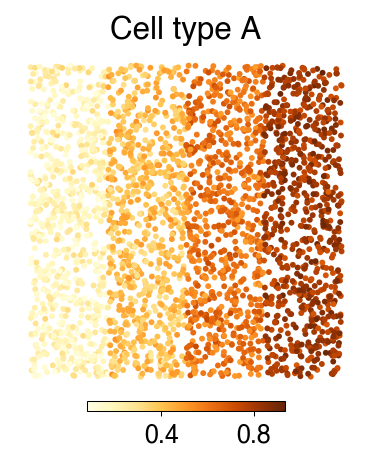

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

ct = 'Ext_L23'  
data = proportion

fig, ax = plt.subplots(figsize=(3.5, 3.2))
#norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
sc = ax.scatter(
    x,
    y,
    c=data,
    s=8,
    cmap='YlOrBr',
    linewidths=0,
    #norm=norm
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
cb.locator = MaxNLocator(nbins=1)
cb.update_ticks()
cb.ax.tick_params(labelsize=12)
#cb.set_label('Proportion', fontsize=12)

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Cell type A', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

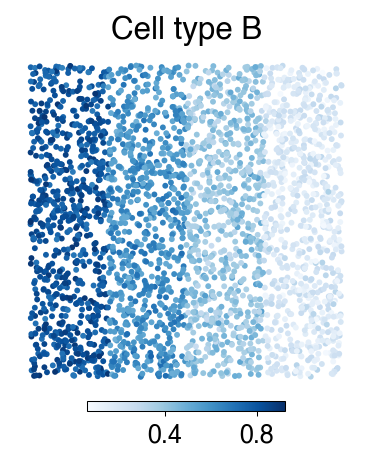

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

data = 1-proportion

fig, ax = plt.subplots(figsize=(3.5, 3.2))
#norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
sc = ax.scatter(
    x,
    y,
    c=data,
    s=8,
    cmap='Blues',
    linewidths=0,
    #norm=norm
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
cb.locator = MaxNLocator(nbins=1)
cb.update_ticks()
cb.ax.tick_params(labelsize=12)
#cb.set_label('Proportion', fontsize=12)

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Cell type B', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [79]:
import seaborn as sns
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent
from matplotlib.colors import ListedColormap, TwoSlopeNorm

In [86]:
new_cmap_2 = set_zero_in_cmap_to_transparent(cmap=sns.color_palette("YlOrBr", as_cmap=True))
colors=new_cmap_2(np.arange(new_cmap_2.N))
colors = colors[0:new_cmap_2.N*3//4]
color2 = colors[new_cmap_2.N//2]


In [87]:
new_cmap_1 = set_zero_in_cmap_to_transparent(cmap=sns.color_palette("Blues", as_cmap=True))
colors=new_cmap_1(np.arange(new_cmap_1.N))
colors = colors[0:new_cmap_1.N*3//4]
color1 = colors[new_cmap_1.N//2]

In [88]:
color1

array([0.41708574, 0.68063053, 0.83823145, 1.        ])

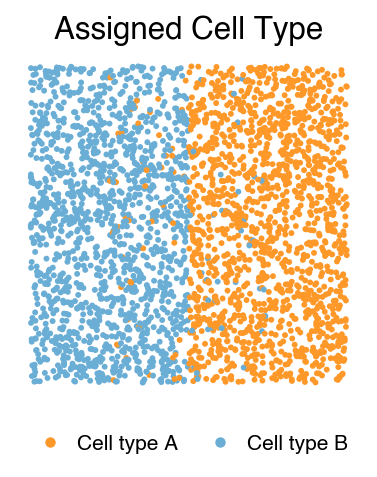

In [91]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

ct = 'Ext_L23'
data = adata_st.obs['ct']

# 将categorical数据转为codes和labels
if hasattr(data, 'cat'):
    categories = data.cat.categories.tolist()
    codes = data.cat.codes.values
else:
    categories = sorted(data.unique())
    cat_map = {c: i for i, c in enumerate(categories)}
    codes = np.array([cat_map[v] for v in data])

n_cats = len(categories)

# 离散colormap
# 直接指定两个category的颜色
color_dict = {
    'celltype_0': color2,   # 红色
    'celltype_1': color1,   # 蓝色
}

# 替换成你的实际category名称和颜色
colors = [color_dict[c] for c in categories]
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(3.5, 3.2))
sc = ax.scatter(
    x,
    y,
    c=codes,
    s=8,
    cmap=cmap,
    norm=norm,
    linewidths=0,
)

# 用legend代替colorbar，更适合categorical数据
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colors[i], markersize=6, label=categories[i])
    for i in range(n_cats)
]
ax.legend(
    handles=handles,
    fontsize=10,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    frameon=False,
    ncol=2,
    handletextpad=0.3,
    columnspacing=1.0,
    labels=['Cell type A', 'Cell type B']
)

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_title('Assigned Cell Type', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

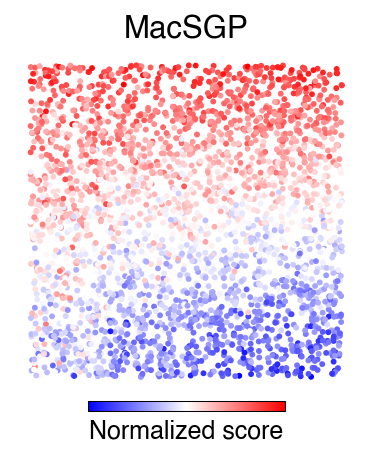

In [57]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

ct = 'Ext_L23'  
data = factor_macsgp_aligned

fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
sc = ax.scatter(
    x,
    y,
    c=data,
    s=8,
    cmap='bwr',
    linewidths=0,
    #norm=norm
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
cb.set_label('Normalized score', fontsize=12)
# no ticks
cb.set_ticks([])

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('MacSGP', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

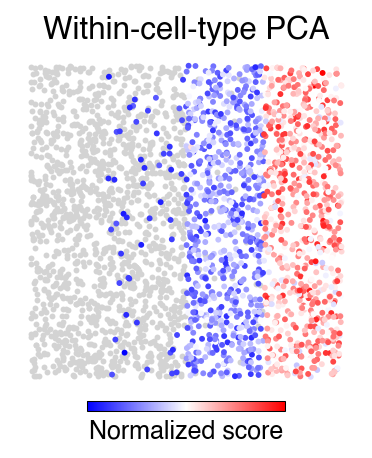

In [93]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
# 把背景设为灰色
ct = 'Ext_L23'  
data = factor_pca_aligned
mask = adata_result.obs['ct'] != 'celltype_0'  # 只显示celltype_0的PCA结果，其他cell type的点用灰色显示
fig, ax = plt.subplots(figsize=(3.5, 3.2))
sc = ax.scatter(
    x[mask],
    y[mask],
    c='lightgray',
    s=8,
    linewidths=0,
)
norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
sc = ax.scatter(
    x[~mask],
    y[~mask],
    c=data[~mask],
    s=8,
    cmap='bwr',
    linewidths=0,
    #norm=norm
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
cb.set_label('Normalized score', fontsize=12)
# no ticks
cb.set_ticks([])

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Within-cell-type PCA', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

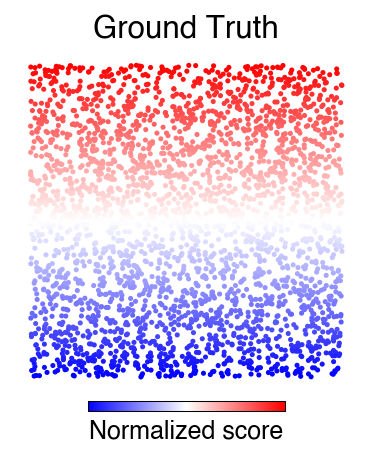

In [86]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

ct = 'Ext_L23'  
data = factor_true.values

fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
sc = ax.scatter(
    x,
    y,
    c=data,
    s=6,
    cmap='bwr',
    linewidths=0,
    #norm=norm
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
cb.set_label('Normalized score', fontsize=12)
# no ticks
cb.set_ticks([])

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Ground Truth', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

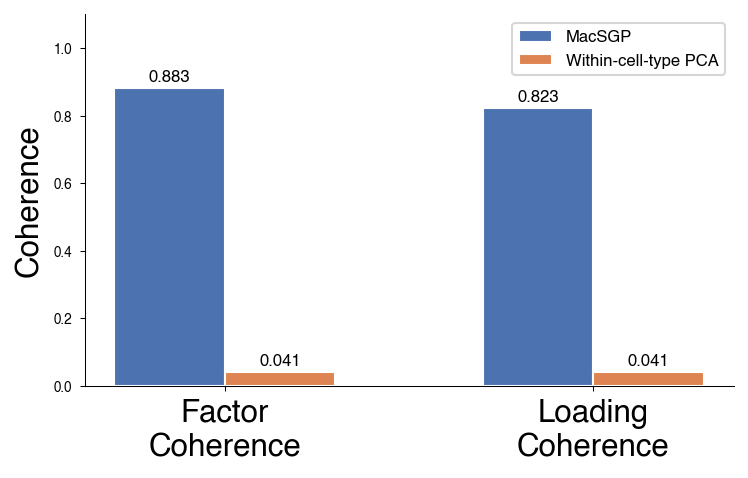

In [67]:
# 图5: Coherence Comparison
fig, ax = plt.subplots(figsize=(5, 3.2))
bar_w = 0.3
x_pos = np.arange(2)
bars1 = ax.bar(x_pos - bar_w/2, macsgp_scores, bar_w,
               label='MacSGP', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x_pos + bar_w/2, pca_scores, bar_w,
               label='Within-cell-type PCA', color='#DD8452', edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(['Factor\nCoherence', 'Loading\nCoherence'], fontsize=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Coherence', fontsize=15)
#ax.set_title('Coherence Comparison', fontsize=15)
ax.legend(fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
